In [1]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

12.4
True
1


In [2]:
import sys
import os
import pickle
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

# Add the src directory to sys.path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(src_path)

from src.IndependentSteps import Pycromanager2NativeDataType, FFF2NativeDataType, Make_Output_Dir_JF, Make_Analysis_Dir_JF, \
                                    ConsolidateImageShapes, TrimZSlices, AutomaticSpotDetection_JF

from src.SequentialSteps import CellSegmentationStepClass_JF, BIGFISH_SpotDetection, SimpleCellposeSegmentaion, rescale_images, remove_background, \
                                exposure_correction, TrackPy_SpotDetection

from src.FinalizationSteps import BuildPDFReport, SaveSpotDetectionResults, SaveMasksToAnalysis, SendAnalysisToNAS

from src import Experiment, Settings, ScopeClass, Pipeline, DataContainer

print('Will it blend?')

Will it blend?


In [3]:
# raw_data_dir = r'C:\Users\Jack\Desktop\H128_Tiles_100ms_5mW_Blue_15x15_10z_05step_2'
raw_data_dir = r'smFISH_images\Eric_smFISH_images\20230511\DUSP1_DexTimeConcSweep_10nM_75min_041223'
# Build Setting Classes
pipelineSettings = Settings(user_select_number_of_images_to_run=3, local_or_NAS=0)
pipelineSettings.verbose = True
pipelineSettings.bigfish_min_threshold = 0
pipelineSettings.bigfish_alpha = 0.8
pipelineSettings.bigfish_min_threshold = 10
pipelineSettings.cellpose_diameter = 150
pipelineSettings.cellpose_model_type = ['cyto3', 'nuclei']
pipelineSettings.display_plots = True
pipelineSettings.MINIMAL_NUMBER_OF_Z_SLICES_TO_CONSIDER_A_3D_IMAGE = 5
pipelineSettings.load_in_mask = True
pipelineSettings.luis_trick = False

pipelineSettings.spot_yx_px = 5
pipelineSettings.spot_z_px = 3



terminatorScope = ScopeClass()
terminatorScope.voxel_size_yx = 160
terminatorScope.spot_yx = 180
terminatorScope.spot_z = 360


experiment = Experiment()
experiment.initial_data_location = raw_data_dir
experiment.cytoChannel = [1]
experiment.nucChannel = [2]
experiment.FISHChannel = [0]
experiment.voxel_size_z = 500

pipelineData = DataContainer()

# Create Pipeline 
prePipelineSteps = [FFF2NativeDataType(), Make_Output_Dir_JF(), Make_Analysis_Dir_JF()] #remove_background(), exposure_correction()]
pipelineSteps = [TrackPy_SpotDetection()]
postPipelineSteps = [BuildPDFReport(), SaveSpotDetectionResults(), SaveMasksToAnalysis()]
pipeline = Pipeline(pipelineSettings, terminatorScope, experiment, pipelineData, prePipelineSteps, postPipelineSteps, pipelineSteps)


The following parameters are required in the run the pipeline
['list_images', 'df_cellresults', 'analysis_location', 'voxel_size_yx', 'df_clusterresults', 'spot_z_px', 'id', 'kwargs', 'FISHChannel', 'map_id_imgprops', 'nucChannel', 'output_location', 'initial_data_location', 'spot_yx_px', 'voxel_size_z', 'df_spotresults']


FFF2NativeDataType
FFF2NativeDataType did not return a value
Make_Output_Dir_JF
Make_Analysis_Dir_JF

 ###################### 
        IMAGE : 0
 ###################### 
    Image Name :   masks_cyto_no_nuclei_ROI001_XY1683820102_Z00_T0_merged

 ###################### 
        IMAGE : 1
 ###################### 
    Image Name :   masks_cyto_no_nuclei_ROI002_XY1683820103_Z00_T0_merged

 ###################### 
        IMAGE : 2
 ###################### 
    Image Name :   masks_cyto_no_nuclei_ROI003_XY1683820104_Z00_T0_merged


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


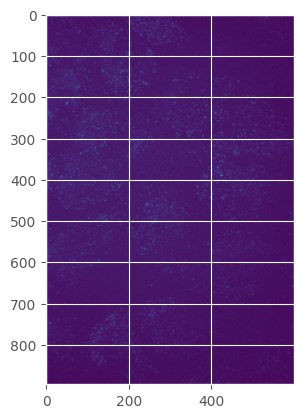

In [4]:
pipeline.run_up_to('TrackPy_SpotDetection')
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(np.max(pipelineData.list_images[0], axis=0)[:,:, 0])
plt.show()

In [5]:
# pipeline.run_single_step(SimpleCellposeSegmentaion(), {'bigfish_alpha': 0.2})

In [6]:
pipeline.run_single_step(TrackPy_SpotDetection())


 ###################### 
        IMAGE : 0
 ###################### 
    Image Name :   masks_cyto_no_nuclei_ROI001_XY1683820102_Z00_T0_merged


DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=557)
           2	RESUME(arg=0, lineno=557)
           4	LOAD_CONST(arg=1, lineno=563)
           6	STORE_FAST(arg=22, lineno=563)
           8	LOAD_FAST(arg=4, lineno=564)
          10	LOAD_FAST(arg=3, lineno=564)
          12	COMPARE_OP(arg=40, lineno=564)
          16	COPY(arg=1, lineno=564)
          18	POP_JUMP_IF_FALSE(arg=5, lineno=564)
          20	POP_TOP(arg=None, lineno=564)
          22	LOAD_FAST(arg=4, lineno=564)
          24	LOAD_FAST(arg=2, lineno=564)
          26	COMPARE_OP(arg=40, lineno=564)
>         30	STORE_FAST(arg=23, lineno=564)
          32	LOAD_FAST(arg=23, lineno=565)
          34	POP_JUMP_IF_FALSE(arg=9, lineno=565)
          36	LOAD_CONST(arg=2, lineno=566)
          38	STORE_FAST(arg=24, lineno=566)
          40	LOAD_CONST(arg=3, lineno=567)
          42	STORE_FAST(arg=25, lineno=567)
          44	LOAD_CONST(arg=4, lineno=568)
          46	STORE_FAST(arg=26, lineno=568)
          

TypeError: Parameter array should be a ndarray. It is a 'tuple' instead.

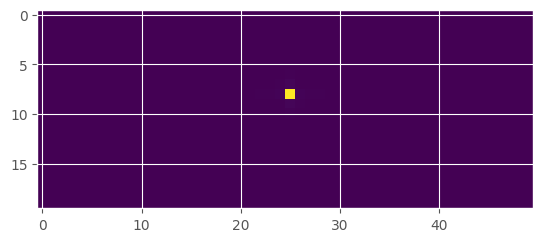

In [7]:
from scipy.fft import fftn, fftshift

rna = pipelineData.list_images[0][:, :, :, 0]
rna = np.max(rna, axis=0)
ft = fftshift(np.abs(fftn(rna)))
plt.imshow(ft[440:460, 275:325])
plt.show()
